# Lecture 18 - The Perceptron Algorithm & Gradient Descent

In [1]:
from IPython.display import Image

# The Perceptron

The Perceptron is one of the simplest Artificial Neural Network (ANN) architectures, invented in 1957 by Frank Rosenblatt. Rosenblatt published the first concept of the perceptron learning rule based on the McCulloch-Pitts Neuron (MCP) neuron model:

* F. Rosenblatt, "The Perceptron, A Perceiving and Recognizing Automaton". Cornell Aeronautical Laboratory, 1957 

* https://news.cornell.edu/stories/2019/09/professors-perceptron-paved-way-ai-60-years-too-soon

With his perceptron rule, Rosenblatt proposed an algorithm that would **"automatically learn the optimal weight coefficients"** that are then multiplied with the input features in order to make the decision of whether a neuron fires or not. In the context of supervised learning and classification, such an algorithm could then be used to predict if a sample belonged to one class or the other.

More formally, we can pose this problem as a **binary classification task** where we refer to our two classes as 1 (positive class) and -1 (negative class) for simplicity.

A basic model for a neuron consists of the following: 

* A set of *synapses* each of which is characterized by *weights* (which includes a *bias*).

* An *adder*.

* An *activation function* (e.g. linear function)

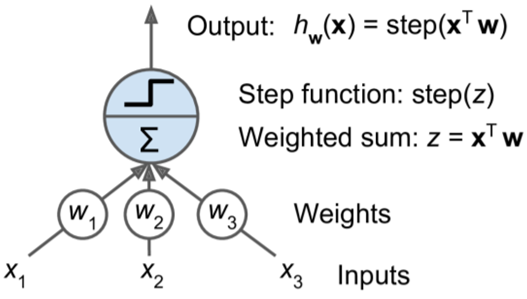

In [2]:
from IPython.display import Image
Image('figures/perceptron.png', width=400)
#Source: Aurélien Géron, "Hands-on Machine Learning with Scikit-Learn, Keras and Tensorflow"

Led to the first AI boom!

![Rosenblatt Article 1958](https://tripleampersand.org/wp-content/uploads/2020/04/Alexander-L.-Cicchinelli-Collector.-Frank-Rosenblatt-Publications-17-1-3370.-Division-of-Rare-and-Manuscript-Collections-Cornell-University-Library.-782x1024.jpg)
<center> Research Trends, Cornell Aeronautical Laboratory, 1958 </center>

![](https://s1.nyt.com/timesmachine/pages/1/1987/09/15/490687_360W.png?quality=75&auto=webp&disable=upscale)
<center> "More Human than Ever, Computer is Learning to Learn", New York Times, September 15, 1987, Section C, Page 1 </center>

## Assumptions
1) Two class classification problem  
2) Linearly separable classes - decision boundary is a hyperplane (linear decision boundary)

## Problem formation

We can write the forward function mathematically as: 

$$y = \phi\left(v\right)$$

where 

$$v =  \sum_{j=1}^m w_j x_j + w_0 = \mathbf{w}^T\mathbf{x} + w_0 $$

and $\phi(x) = \begin{cases}1, & x>0\\ -1, & x<0\end{cases}$, or equivalently $\phi(x) = sign(x)$, and $w_0$ is a scalar, sometimes also referred to as the bias, $b$.
    
* *What does this look like graphically?*

## Error function and learning algoirithm

Consider an alternative **objective function** known as the **perceptron criterion**.  
To derive this, we note that we are seeking a weight vector $\mathbf{w}$ such that:  
1) the inputs $\mathbf{x}_n$ in class $C_1$ will have $\mathbf{w}^T\mathbf{x}_n + w_0 > 0$, and  
2) the inputs $\mathbf{x}_n$ in class $C_2$ have $\mathbf{w}^T\mathbf{x}_n + w_0 < 0$.  
Using the $t\in \{-1,1\}$ target coding scheme it follows that we would like all patterns to satisfy

$$(\mathbf{w}^T\mathbf{x}_n + w_0)t_n > 0$$

* The perceptron criterion associates zero error with any pattern that is correctly classified, whereas for a misclassified pattern $x_i$ it tries to minimize the quantity $-(\mathbf{w}^T\mathbf{x}_n + w_0)t_n$.

* The perceptron objective function is therefore given by:

$$J(\mathbf{w},w_0) = - \sum_{n\in\mathcal{M}} (\mathbf{w}^T \mathbf{x}_n + w_0) t_n$$

where $\mathcal{M}$ denotes the set of all misclassified patterns.

We now apply the **stochastic gradient descent** algorithm to this error function, and an update is made for an individual misclassified sample. The change in the weight vector $\mathbf{w}$ is then given by:

\begin{align*}
\mathbf{w}^{(t+1)} &\leftarrow  \mathbf{w}^{(t)} - \eta \frac{\partial E_p(\mathbf{w},b)}{\partial \mathbf{w}} = \mathbf{w}^{(t)} + \eta \mathbf{x}_n t_n\\
w_0^{(t+1)} &\leftarrow w_0^{(t)} - \eta\frac{\partial E_p(\mathbf{w},w_0)}{\partial w_0} = w_0^{(t)} + \eta t_n
\end{align*}

where $\eta$ is the **learning rate** hyperparameter and the superscript $t$ is an integer that indexes the iteration steps of the algorithm. We do not cease updating until the *entire dataset* is correctly classified.  
* Using a single sample to make an update is also referred to as **online learning**. 

* Note that, as the weight vector evolves during training, the set of patterns that are misclassified will change.

When the model has seen every sample in the dataset, it has completed one **epoch** (a complete pass of the training data). This is depicted by the for loop in the pseudocode below.

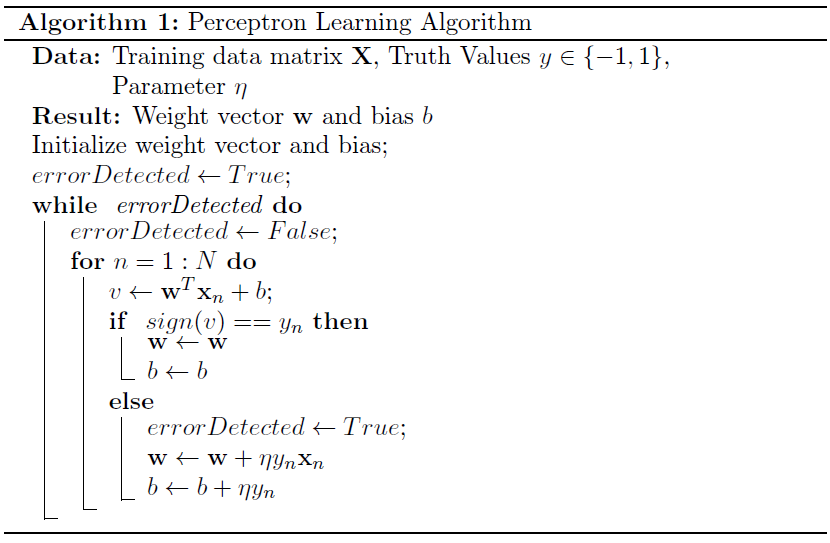

In [3]:
Image('figures/PerceptronLearning.png', width=700)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
np.random.seed(314152)

In [5]:
def generateMVNRandData(Npts, mu, sigma):
    '''This function generates random Gaussian data'''
    np.random.seed(314152)
    data  = np.random.multivariate_normal(mu, sigma*np.eye(len(mu)), Npts)
    return data

# def plotLine(weights, interval):
#     '''This function plots the discriminant function given its weight values.'''
#     x = np.array(interval)
#     y = -(weights[0]/weights[1])-(weights[2]/weights[1])*x
#     plt.plot(x,y)

def plotLine(weights, interval):
    '''This function plots the discriminant function given its weight values.'''
    x = np.array(interval)
    y = -(weights[0]/weights[2])-(weights[1]/weights[2])*x
    plt.plot(x,y)

def perceptronLearningAlg(data,labels,eta,nEpochs):
    '''This function implements the Perceptron Learning 
    algorithm on a given training data (without extra graphs).'''
    nPts = data.shape[0]
    np.random.seed(314152) # edit
    weights = np.random.rand(data.shape[1])
    print('Initial weights:', weights)
    
    error = 1
    epo = 0
    while(error > 0 and epo < nEpochs):
        print('Epoch: ', epo)
        error = 0
        epo += 1
        for i in range(nPts):
            v =  data[i,:]@weights
            if np.sign(v) != labels[i]:
                # Online learning
                weights += eta*data[i,:]*labels[i]
                error += 1
                plt.scatter(data[:,1],data[:,2], c=labels, linewidth=0)
                plotLine(weights, [-3,3]);
                plt.pause(0.5)
    
    print('Final weights:', weights)
    return weights

In [6]:
def perceptronLearningAlg(data,labels,eta,nEpochs,normalize_vecs=True):
    '''This function implements the Perceptron Learning 
    algorithm on a given training data (with extra graphs).'''
    nPts = data.shape[0]
    np.random.seed(314152)
    weights = np.random.rand(data.shape[1])
    print('Initial weights:', weights,'\n')
    
    error = 1
    epo = 0
    while(error > 0 and epo < nEpochs):
        error = 0
        epo += 1
        vs = data@weights 
        print('\n Start of epoch ',epo,', Correct: ', sum(np.sign(vs)==labels),'/',nPts) 
        for i in range(nPts):
            v =  data[i,:]@weights
            if np.sign(v) != labels[i]:
                # Plotting the data, hyperplane for the old weight vector, and highlighting selected data point
                plt.xlim([-5,5])
                plt.ylim([-5,5])
                plt.scatter(data[:,1],data[:,2], c=labels, linewidth=0)  # data
                plt.plot(data[i,1],data[i,2],marker='x',ms = 12, markeredgewidth=3, color='orange')
                plt.quiver(0,0,data[i,1],data[i,2], color='orange',
                           angles='xy', scale_units='xy', scale=1,label = 'input data vector')
                plotLine(weights, [-5,5]); # old hyperplane
                
                # Plotting weight vector and gradient vector
                coord1 = 1
                coord2 = -weights[0]/weights[2] -weights[1]/weights[2]*coord1 # plug into y = mx+b to get coords
                if normalize_vecs:
                    weights_norm = np.sqrt(weights[1]**2+weights[2]**2) # normalizing the vectors just for visual!
                else:
                    weights_norm=1
                plt.quiver(coord1,coord2, weights[1]/weights_norm, weights[2]/weights_norm,
                           color='b', angles='xy', scale_units='xy', scale=1,label='old weight vector'); 
                
                lr_grad = eta*data[i,:]*labels[i] # gradient or update vector
                if normalize_vecs:
                    lr_grad_norm = np.sqrt(lr_grad[1]**2+lr_grad[2]**2) # normalizing again for visual
                else: 
                    lr_grad_norm = 1
                plt.quiver(coord1+(weights[1]/weights_norm),coord2+(weights[2]/weights_norm), # just vector addition to get new points
                           lr_grad[1]/lr_grad_norm,lr_grad[2]/lr_grad_norm,
                           color='g',angles='xy', scale_units='xy', scale=1,label='gradient'); 
                plt.legend(loc='lower left')
                plt.title('Old weights and gradient update')
                plt.pause(0.5)
                
                #### Stochastic gradient descent - this is the learning algo! ####
                # (you don't need anything else - the rest of this fxn is all plotting)
                weights += eta*data[i,:]*labels[i] # update!
                error += 1 # tracking errors
                
                # Separate graph for visualizing new w_t
                plt.scatter(data[:,1],data[:,2], c=labels, linewidth=0) # data
                plt.xlim([-5,5])
                plt.ylim([-5,5])
                coord1 = 1
                coord2 = -weights[0]/weights[2] -weights[1]/weights[2]*coord1
                plt.quiver(coord1,coord2, weights[1],weights[2],
                           color='c',label='new weight vector',angles='xy', scale_units='xy', scale=1);
                plt.legend(loc='lower left')
                plotLine(weights, [-5,5]); # new hyperplane
                plt.title('New weights and hyperplane')
                plt.pause(0.5)
                
                # Checking the number of correct samples after updating
                vs = data@weights
                print('After update ',error,', Correct: ', sum(np.sign(vs)==labels),'/',nPts) # addition
    print('Final weights:', weights)
    return weights

## Create and visualize the data

In [ ]:
Npts  = 100
mu1   = [2,2]
mu2   = [0,0] 
var   = .1

data1 = np.array(generateMVNRandData(Npts, mu1, var)) # positive
data1 = np.hstack((np.ones((Npts,1)),data1))

data2 = np.array(generateMVNRandData(Npts, mu2, var)) # negative
data2 = np.hstack((np.ones((Npts,1)),data2))

data  = np.vstack((data1, data2))
labels= np.hstack((np.ones(Npts), -np.ones(Npts)))

plt.scatter(data1[:,1],data1[:,2], linewidth=0,c='yellow',label='positive class')
plt.scatter(data2[:,1],data2[:,2], linewidth=0,c='purple',label='negative class')
plt.legend()
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.xlabel('x1')
plt.ylabel('x2')

data.shape, labels.shape # Why does the data shape (200,3) have an extra dimension?

In [ ]:
###### Visualize our initial weight vector guess #####
Npts  = 100
mu1   = [2,2]
mu2   = [0,0] 
var   = .1

data1 = np.array(generateMVNRandData(Npts, mu1, var)) # positive
data1 = np.hstack((np.ones((Npts,1)),data1))

data2 = np.array(generateMVNRandData(Npts, mu2, var)) # negative
data2 = np.hstack((np.ones((Npts,1)),data2))

data  = np.vstack((data1, data2))
labels= np.hstack((np.ones(Npts), -np.ones(Npts)))

plt.scatter(data[:,1],data[:,2], c=labels, linewidth=0)
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.xlabel('x1')
plt.ylabel('x2')

np.random.seed(314152)
weights = np.random.rand(data.shape[1])
plotLine(weights,[-3,3])


h1 = 1
h2 = -weights[0]/weights[2] -weights[1]/weights[2]*h1
weights_norm = np.sqrt(weights[1]**2+weights[2]**2)
plt.quiver(h1,h2,weights[1]/weights_norm,weights[2]/weights_norm, # weight vector describing the decision boundary
           color = 'c',label='weight vector',
           angles='xy', scale_units='xy', scale=1);

In [9]:
# Proof that weight vector is perpendicular to the hyperplane

hyper_vec = np.array([1,-weights[1]/weights[2]]) # from transformation to y=mx+b
weight_vec = np.array([weights[1],weights[2]])
hyper_vec.T@weight_vec # inner product

np.float64(0.0)

## Implementing the learning algorithm

In [ ]:
eta   = 0.5 # learning rate
nEpochs = 10; # maximum number of epochs

weights = perceptronLearningAlg(data,labels,eta,nEpochs,normalize_vecs=True); 
# (if the vecs are normalized, the addition isn't a perfect representation of the new weight vec)

In [ ]:
plt.scatter(data[:,1],data[:,2], c=-labels, linewidth=0)
plt.xlim([-3,3])
plt.ylim([-3,3])
plotLine(weights,[-3,3])

### Adjusting the learning rate

In [ ]:
eta   = 0.001
nEpochs = 10;

plt.scatter(data[:,1],data[:,2], c=labels, linewidth=0)
plt.xlim([-3,3])
plt.ylim([-3,3])

weights = perceptronLearningAlg(data,labels,eta,nEpochs);

### Adjusting the distance between clusters

In [ ]:
Npts  = 100
mu1   = [2,2]
mu2   = [0.75,0.75] # [0.75,0.75] 
var   = .1

data1 = np.array(generateMVNRandData(Npts, mu1, var)) # positive
data1 = np.hstack((np.ones((Npts,1)),data1))

data2 = np.array(generateMVNRandData(Npts, mu2, var)) # negative
data2 = np.hstack((np.ones((Npts,1)),data2))

data  = np.vstack((data1, data2))
labels= np.hstack((np.ones(Npts), -np.ones(Npts)))


eta   = 0.5 
nEpochs = 15; 

# plt.scatter(data1[:,1],data1[:,2], c='yellow', linewidth=0,label = 'positive')
# plt.scatter(data2[:,1],data2[:,2], c='purple', linewidth=0,label = 'negative')
# plt.legend(loc='lower left')
# plt.xlim([-3,3])
# plt.ylim([-3,3])

weights = perceptronLearningAlg(data,labels,eta,nEpochs);

## Many possible solutions for a hyperplane
(if the classes are not relatively close)

In [ ]:
# Many possible solutions for a hyperplane

Npts  = 100
mu1   = [2,2]
mu2   = [0,0] 
var   = .1 # -> .2

data1 = np.array(generateMVNRandData(Npts, mu1, var)) # positive
data1 = np.hstack((np.ones((Npts,1)),data1))

data2 = np.array(generateMVNRandData(Npts, mu2, var)) # negative
data2 = np.hstack((np.ones((Npts,1)),data2))

data  = np.vstack((data1, data2))
labels= np.hstack((np.ones(Npts), -np.ones(Npts)))

plt.scatter(data[:,1],data[:,2], c=labels, linewidth=0)
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.xlabel('x1')
plt.ylabel('x2');

plotLine([2.8,-1.8,-1],[-3,3]) # first input to plotLine is weight matrix of form [w0,w1,w2] -> x2 = -w1/w2*x + w0/w2
#plotLine([2.15,-2.1,-1],[-3,3])

---

## Perceptron Convergence Theorem

The *Perceptron convergence theorem* states that for any data set which is **linearly separable** the perceptron learning algorithm is **guaranteed to find *a* solution** in a finite number of steps.

* In other words, the Perceptron learning rule is guaranteed to converge to a weight vector that correctly classifies the examples provided the training examples are linearly separable.

---

## Wow, perceptrons fooled by this one simple trick (XOR problem)

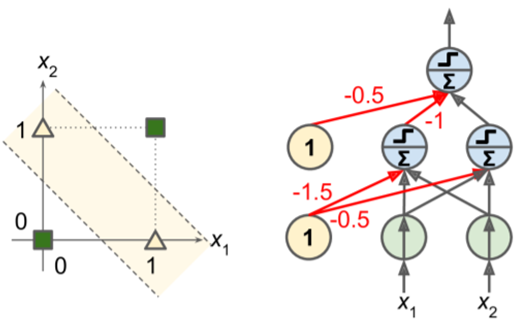

In [13]:
Image('figures/XOR_problem.png',width=400)
#Source: Aurélien Géron, "Hands-on Machine Learning with Scikit-Learn, Keras and Tensorflow"

A single perceptron cannot solve the simple XOR problem, which led to the first AI Winter in 1974-1980 (more info at end of notebook) and SVMs became the standard model. However, this limitation can be overcome via stacking perceptrons in series and parallel in a new artificial neural network known as the **multi-layer perceptron (MLP)**, depicted on the right side of the figure above. An MLP can solve the XOR problem, which can be verified by computing the output of the depicted MLP.   
But, at the time, an automatic learning algorithm for updating the parameters (weight connections of a MLP) did not exist. This algorithm was not introduced until 1979 and then popularized in a [famous paper in 1986](https://www.nature.com/articles/323533a0). This algorithm is known as the **backpropagation** algorithm.
MLPs and backpropagation will be introduced in later lectures. 

---

## The Mark I Perceptron

Frank Rosenblatt's perceptron was implemented in hardware that got the name of **Mark I Perceptron**.

The weights were encoded in potentiometers, and weight updates were done by electric motors.

![](https://ids.si.edu/ids/deliveryService?id=SIA-MAH-64770&max=1000)
<center>Perceptron, Mark I. National Museum of American History.</center>

![The Perceptron](https://tripleampersand.org/wp-content/uploads/2020/04/Mark-I-Perceptron-at-the-Cornell-Aeronautical-Laboratory-834x1024.jpg)
<center> Mark I Perceptron </center>

![Mark I Perceptron](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRRZt_zoi1NoWvjR-F6pE-MAqVOXC3zorhesfc-Q40kJfJRPyucZam_GptQJJ0kpNlbHgo&usqp=CAU)
<center> Frank Rosenblatt holding an array of potentiometers </center>

![Character Recognition](https://news.cornell.edu/sites/default/files/styles/full_size/public/2019-09/0925_rosenblatt5.jpg?itok=YuOn88nZ)

# Exercise

1. Consider a neuron with two inputs and one output and a step function. If two weights are $w_1=1$ and $w_2 =1$, and the bias is $b=-1.5$, then what is the output for inputs $(0,0)$, $(1,0)$, $(0,1)$, and $(1,1)$?

2. How does the learning behavior change with changes in $\eta$? as $\eta$ increases? as $\eta$ decreases?

3. How would you generate overlapping classes using the provided code? Explain your answer. (Only change parameters. You do not need to change code.)

4. What happens to the learning behavior when you have overlapping classes?

5. The implementation provided uses $\{-1,1\}$ labels. Suppose we want to use labels $\{0,1\}$. How can we formulate the Perceptron Learning? How does the code need to change to account for this difference (i.e., suppose you want to use $\{0,1\}$ labels. What would you need to change in the code?) Why? 

6. In the provided code, there is not a separate line for learning the bias $b$ as in the pseudo-code above. How is it being estimated and represented it in the code? (the code is still learning the bias value).

---

## Perceptron Learning Algorithm 
### Connection to neuron inspiration

The Perceptron training algorithm proposed by Frank Rosenblatt was largely inspired by Hebb’s rule. In his book *The Organization of Behavior*, published in 1949, Donald Hebb suggested that when a biological neuron often triggers another neuron, the connection between these two neurons grows stronger. 

Hebbian theory is a neuroscientific theory claiming that an increase in synaptic efficacy arises from a presynaptic cell's repeated and persistent stimulation of a postsynaptic cell. It is an attempt to explain synaptic plasticity, the adaptation of brain neurons during the learning process. It was introduced by Donald Hebb in his 1949 book "The Organization of Behavior". The theory is also called **Hebb's rule**, **Hebb's postulate**, and **cell assembly theory**.

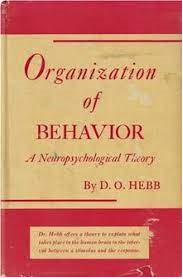

In [14]:
Image('figures/Hebb.png',width=250)

> *Let us assume that the persistence or repetition of a reverberatory activity (or "trace") tends to induce lasting cellular changes that add to its stability. ... When an axon of cell A is near enough to excite a cell B and repeatedly or persistently takes part in firing it, some growth process or metabolic change takes place in one or both cells such that A’s efficiency, as one of the cells firing B, is increased.* - Donald O. Hebb, 1949

This idea was later summarized by **Siegrid Löwel** in her catchy phrase: **"Cells that fire together, wire together."** This rule later became known as Hebb's rule or **Hebbian learning**; that is, the connection weight between two neurons is increased whenever they have the same output. 

Perceptrons are trained using a variant of this rule that takes into account the error made by the network; it reinforces connections that help reduce the error. More specifically, the Perceptron starts by initializing the weight connections at random. 

Then it is fed one training instance at a time, and for each instance it makes its predictions. 

For every output neuron that produced a wrong prediction, it reinforces the connection weights from the inputs that would have contributed to the correct prediction.

The decision boundary of each output neuron is linear, so Perceptrons are incapable of learning complex patterns. However, **if the training instances are linearly separable**, Rosenblatt demonstrated that this algorithm would converge to a solution. This is called the **Perceptron convergence theorem**.

### ADALINE by Widrow and Hoff, 1959

The **ADALINE (Adaptive Linear Neuron)** was introduced in 1959, shortly after Rosenblatt's perceptron, by Bernard Widrow and Ted Hoff (one of the inventors of the **microprocessor**) at Stanford. Widrow and Hoff were **electrical engineers**, yet Widrow had attended the famous Dartmouth workshop on artificial intelligence in 1956, an experience that got him interested in the idea of building brain-like artificial learning systems.

The main difference between the perceptron and the ADALINE is that the later works by minimizing the **mean squared error** of the predictions of a linear function. This means that the learning procedure is based on the outcome of a linear function rather than on the outcome of a threshold function as in the perceptron.

* From a cognitive science perspective, the main contribution of the ADALINE was methodological rather than theoretical.

* The main application of the ADALINE was in adaptive filtering and adaptive signal processing
    * Technologies like adaptive antennas, adaptive noise canceling, and adaptive equalization in high-speed modems (which makes Wifi works well), were developed by using the ADALINE (Widrow & Lehr, 1990).
    
![The ADALINE](https://pabloinsente.github.io/assets/post-6/adaline-math.png)    

Mathematically, learning from the output of a linear function enables the minimization of a continuous **cost or loss function**. Continuous cost functions have the advantage of having "*nice*" derivatives, that facilitate training neural nets by using the **chain rule of calculus**. This change opened the door to train more complex algorithms like non-linear multilayer perceptrons, logistic regression, support vector machines, and others.

<!-- Learn more from [The ADALINE](https://pabloinsente.github.io/the-adaline) blog post. -->

## 1st AI Winter, 1974-1980

In their 1969 monograph titled Perceptrons, Marvin Minsky and Seymour Papert highlighted a number of serious weaknesses of Perceptrons, in particular the fact that **Perceptrons are incapable of solving some trivial problems such as the Exclusive OR**, XOR, classification problem. Of course, this is true of any other linear classification model as well, but researchers had expected much more from Perceptrons, and their disappointment was great, and many researchers dropped neural networks altogether in favor of higher-level problems such as logic, problem solving, and search. This monograph brought the **first AI winter**.

![Minsky and Papert 1969 book editions](https://pictures.abebooks.com/inventory/30588259910.jpg)

However, it turns out that some of the limitations of Perceptrons can be eliminated by stacking multiple Perceptrons. The resulting ANN is called a Multi-Layer Perceptron, or MLP. In particular, an MLP can solve the XOR problem, as you can verify by computing the output of the MLP represented on the right side of this figure.

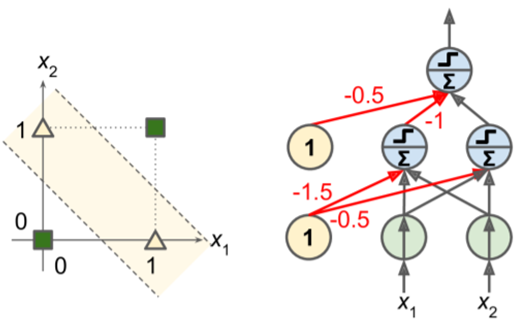

In [15]:
Image('figures/XOR_problem.png',width=400)
#Source: Aurélien Géron, "Hands-on Machine Learning with Scikit-Learn, Keras and Tensorflow"

But, at the time, an automatic learning algorithm for updating the parameters (weight connections of a multi-layer perceptron) did not exist. This algorithm was not introduced until 1979 and then popularized in a [famous paper in 1986](https://www.nature.com/articles/323533a0). This algorithm is known as the **backpropagation algorithm**.

Until then, **Support Vector Machines (SVM)** became the status-quo in machine learning.

---